**Goal:**
- Recognize license plate text from cropped plate images using LPRNet
- Measure recognition confidence and latency
- Save structured results for identity matching
- Prepare reusable functions for source integration

In [11]:
# import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import cv2
import os
import numpy as np
from PIL import Image
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import random

In [12]:
# Define the CHARS and BLANK_INDEX for LPRNet
CHARS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
         'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K',
         'L', 'M', 'N', 'O','P', 'Q', 'R', 'S', 'T', 'U', 'V',
         'W', 'X', 'Y', 'Z', '-']

# LPRNet requires a BLANK character for CTC Loss
BLANK_INDEX = len(CHARS) 
NUM_CLASSES = len(CHARS) + 1

char_to_idx = {char: i for i, char in enumerate(CHARS)}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
#  Add project root to sys.path for local imports
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [14]:
# Import local modules
from src.configs.settings import settings

In [15]:
# Configs
INPUT_DIR = settings.LICENSE_INPUT_DIR 
TRAIN_DIR = INPUT_DIR / "train"
VAL_DIR = INPUT_DIR / "val"
OUTPUT_DIR = settings.LICENSE_OUTPUT_DIR

In [16]:
# Define the Dataset class for LPRNet
class LPRDataset(Dataset):
    def __init__(self, root_dir, img_size=(94, 24)):
        self.img_dir = os.path.join(root_dir, 'images')
        self.lbl_dir = os.path.join(root_dir, 'labels')
        self.img_names = os.listdir(self.img_dir)
        self.img_size = img_size

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        # Load Image
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.resize(image, self.img_size)
        image = image.astype('float32') / 255.0
        image = np.transpose(image, (2, 0, 1)) # HWC to CHW

        # Load Label
        lbl_name = img_name.replace('.jpg', '.txt')
        lbl_path = os.path.join(self.lbl_dir, lbl_name)
        with open(lbl_path, 'r') as f:
            label_str = f.read().strip().upper()
        
        # Convert string to indices
        label = [char_to_idx[c] for c in label_str if c in char_to_idx]
        
        return torch.from_numpy(image), torch.IntTensor(label), len(label)

# Collate function to handle variable label lengths in a batch
def collate_fn(batch):
    imgs, labels, lengths = zip(*batch)
    imgs = torch.stack(imgs, 0)
    flat_labels = torch.cat(labels, 0)
    lengths = torch.IntTensor(lengths)
    return imgs, flat_labels, lengths

In [17]:
# LPRNet Model Definition
class BaseBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        mid_channels = out_channels // 4

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_channels, mid_channels, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_channels, mid_channels, kernel_size=(1, 3), padding=(0, 1)),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.block(x)


class LPRNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=(1, 1), padding=1),

            BaseBlock(64, 128),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=(2, 1), padding=1),

            BaseBlock(128, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            BaseBlock(256, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=(2, 1), padding=1),

            nn.Dropout(0.1),

            nn.Conv2d(256, 256, kernel_size=(4, 1)),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout(0.1),

            nn.Conv2d(256, num_classes, kernel_size=(1, 13), padding=(0, 6)),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = torch.mean(x, dim=2)
        return x

In [22]:
# Validation Function
def validate_model(model, val_loader, criterion, device):
    model.eval()
    total_val_loss = 0
    correct_plates = 0
    total_plates = 0
    
    with torch.no_grad():
        for imgs, labels, label_lengths in val_loader:
            imgs = imgs.to(device)
            
            logits = model(imgs)
            logits = logits.permute(2, 0, 1)
            logits = logits.log_softmax(2)
            
            input_lengths = torch.full(size=(logits.size(1),), fill_value=logits.size(0), dtype=torch.int32)
            
            loss = criterion(logits, labels, input_lengths, label_lengths)
            total_val_loss += loss.item()
            
            # Calculate accuracy
            batch_size = logits.size(1)
            for i in range(batch_size):
                # Get logits for this sample: [width, num_classes] -> [1, num_classes, width]
                sample_logits = logits[:, i, :].unsqueeze(0).permute(0, 2, 1)
                pred_str = decode_prediction(sample_logits, CHARS)
                
                # Reconstruct GT string
                start = sum(label_lengths[:i])
                end = start + label_lengths[i]
                gt_str = "".join([CHARS[idx] for idx in labels[start:end]])
                
                if pred_str == gt_str:
                    correct_plates += 1
                total_plates += 1
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (correct_plates / total_plates) * 100 if total_plates > 0 else 0
    return avg_val_loss, val_accuracy

# The Training Loop

# Initialize Data
train_dataset = LPRDataset(root_dir=TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

val_dataset = LPRDataset(root_dir=VAL_DIR)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Initialize Model
model = LPRNet(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CTCLoss(blank=BLANK_INDEX, reduction='mean')

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Early stopping parameters
patience = 10
best_val_loss = float('inf')
epochs_without_improvement = 0
best_model_path = "best_nigerian_lprnet.pth"

epochs = 100

print("Starting Training...")
for epoch in range(epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    
    for imgs, labels, label_lengths in train_loader:
        imgs = imgs.to(device)
        
        # Forward Pass
        logits = model(imgs) 
        logits = logits.permute(2, 0, 1)
        logits = logits.log_softmax(2)
        
        input_lengths = torch.full(size=(logits.size(1),), fill_value=logits.size(0), dtype=torch.int32)
        
        loss = criterion(logits, labels, input_lengths, label_lengths)
        
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    
    # Validation phase
    val_loss, val_accuracy = validate_model(model, val_loader, criterion, device)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print metrics
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")
    
    # Early stopping and model saving
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Validation loss improved. Model saved to {best_model_path}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement in validation loss for {epochs_without_improvement} epochs.")
        
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

# Load the best model
model.load_state_dict(torch.load(best_model_path))
print(f"Best model loaded from {best_model_path}")

# Save the final weights
torch.save(model.state_dict(), "nigerian_lprnet.pth")
print("Final model saved as nigerian_lprnet.pth")

Starting Training...
Epoch 1/100, Train Loss: 4.0660, Val Loss: 2.9602, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 2/100, Train Loss: 2.8012, Val Loss: 2.6943, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 3/100, Train Loss: 2.6807, Val Loss: 2.6460, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 4/100, Train Loss: 2.5684, Val Loss: 2.5169, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 5/100, Train Loss: 2.5045, Val Loss: 2.4834, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 6/100, Train Loss: 2.4517, Val Loss: 2.4782, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 7/100, Train Loss: 2.3960, Val Loss: 2.4263, Val Accuracy: 0.00%
Validation loss improved. Model saved to best_nigerian_lprnet.pth
Epoch 8/100, Train L

**Model Evaluation**

In [23]:
val_dataset = LPRDataset(root_dir=VAL_DIR)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

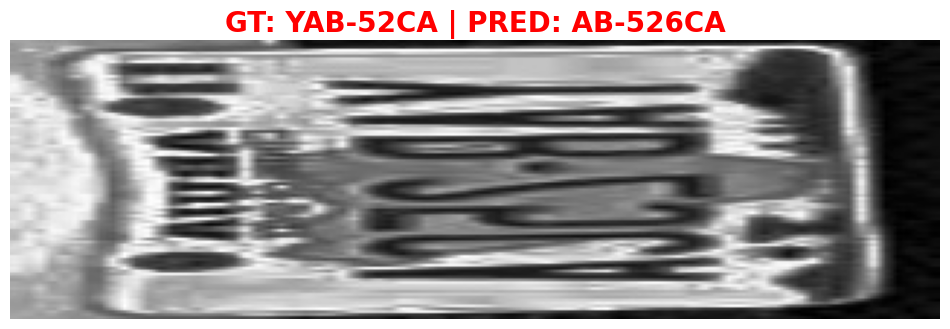

In [28]:
# 1. Select a random sample and get its filename
index = random.randint(0, len(val_dataset) - 1)
img_filename = val_dataset.img_names[index]

# 2. Get the model's processed version for inference
test_img_tensor, ground_truth_indices, _ = val_dataset[index]

# 3. Reload the ORIGINAL high-quality image from your disk
# val_dataset.img_dir is the path to your ".../val/images" folder
original_img_path = os.path.join(val_dataset.img_dir, img_filename)
original_img = cv2.imread(original_img_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) # Fix colors for Matplotlib

# 4. Run Inference on the processed tensor
model.eval()
with torch.no_grad():
    logits = model(test_img_tensor.unsqueeze(0).to(device))
    plate_text_pred = decode_prediction(logits, CHARS)

# 5. Get Ground Truth string
gt_str = "".join([CHARS[idx] for idx in ground_truth_indices.cpu().numpy()])

# 6. Display the High-Quality Original
plt.figure(figsize=(12, 6))
plt.imshow(original_img) # This is now the crisp, original image

# Styling the result
correct = (plate_text_pred == gt_str)
color = 'green' if correct else 'red'
plt.title(f"GT: {gt_str} | PRED: {plate_text_pred}", fontsize=20, color=color, fontweight='bold')
plt.axis('off')
plt.show()

In [29]:
def calculate_accuracy(loader, model):
    model.eval()
    correct_plates = 0
    total_plates = 0
    
    with torch.no_grad():
        for imgs, labels, label_lengths in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            
            # Decode each plate in the batch
            for i in range(logits.size(0)):
                pred_str = decode_prediction(logits[i:i+1], CHARS)
                
                # Reconstruct GT string from flat labels
                start = sum(label_lengths[:i])
                end = start + label_lengths[i]
                gt_str = "".join([CHARS[idx] for idx in labels[start:end]])
                
                if pred_str == gt_str:
                    correct_plates += 1
                total_plates += 1
                
    return (correct_plates / total_plates) * 100

val_acc = calculate_accuracy(val_loader, model)
print(f"Final Validation Plate Accuracy: {val_acc:.2f}%")

Final Validation Plate Accuracy: 10.06%
